# Trabalho Final: Otimização de Alocação de Usinas Solares

**Disciplina:** Otimização (COS360)  
**Instituição:** Universidade Federal do Rio de Janeiro (UFRJ)  
**Aluno:** João Pedro Pereira  
**DRE:** 123642929  

---

## 1. Introdução

O Brasil enfrenta um desafio estratégico para a próxima década: expandir massivamente sua capacidade de geração de energia limpa. O **Plano Decenal de Energia (PDE) 2034** estabelece uma meta de adicionar **25,8 GW** de energia solar à matriz elétrica nacional.

Embora o país tenha vastas áreas com alta incidência solar, escolher onde instalar essas usinas não é uma tarefa fácil. O principal obstáculo não é a falta de sol, mas o **custo de infraestrutura**. Construir usinas em locais distantes da rede elétrica exige investimentos em novas linhas de transmissão e subestações, o que encarece a energia para o consumidor final.

O problema central deste trabalho é: **como selecionar o conjunto ideal de locais para atingir a meta de geração do governo com o menor custo possível de conexão?**

Para resolver essa questão, este projeto utiliza **Otimização Matemática**. Focando no estado de **Minas Gerais**, atual líder nacional em energia solar. Sendo desenvolvido um modelo de otimização capaz de analisar milhares de áreas candidatas simultaneamente. O algoritmo busca o equilíbrio ótimo entre o potencial de geração de cada local e o custo para conectá-lo ao sistema elétrico, oferecendo uma solução baseada em dados para o planejamento energético.

## 2. Modelo Matemático

Para resolver o problema de alocação de usinas, modelamos a região de interesse como uma grade (raster) de células independentes. O problema foi formulado como um modelo de **Programação Inteira Binária (PIB)**.

Diferente de abordagens de simples sobreposição de mapas (álgebra de mapas), este modelo considera as restrições físicas, legais e econômicas simultaneamente dentro de um sistema de equações lineares, garantindo a otimicidade global da solução.

### 2.1. Definição de Conjuntos e Variáveis

Definimos $I$ como o conjunto de todas as áreas candidatas (pixels de $1 \times 1$ km) contidas na região de estudo (Minas Gerais).
Para cada área $i \in I$, definimos uma variável de decisão binária $x_i$:

$$
x_i = \begin{cases}
1 & \text{se a área } i \text{ for selecionada para instalação da usina} \\
0 & \text{caso contrário}
\end{cases}
$$

### 2.2. Parâmetros do Modelo

Cada área $i$ possui atributos geográficos e econômicos que alimentam o modelo:

* $C_i$ — **Custo de Conexão (R\$)**: Representa o custo de infraestrutura (CAPEX) para conectar a usina à subestação mais próxima. É calculado em função da distância euclidiana.
* $P_i$ — **Potencial de Geração (MW)**: Capacidade estimada de geração fotovoltaica, calculada com base na irradiação média local.
* $D_i$ — **Declividade (graus):** Inclinação média do terreno, derivada de dados topográficos.
* $A_i$ — **Indicador de Proteção (Binário):** Assume valor 1 se a área interfere em Unidades de Conservação (UCs), Terras Indígenas (TIs) ou Quilombolas; 0 caso contrário.
* $M$ — **Meta de Expansão (MW):** O total de capacidade instalada que o sistema deve atingir (Target).
* $S_{max}$ — **Declividade Máxima (graus):** Limite físico para viabilidade de terraplanagem e instalação de trackers (assumido como $5^\circ$).

### 2.3. Formulação (Programação Inteira)

#### A. Função Objetivo
O objetivo central é a eficiência econômica. Buscamos minimizar o somatório dos custos de conexão de todas as usinas selecionadas.

$$
\text{Minimizar } Z = \sum_{i \in I} C_i \cdot x_i
$$

#### B. Restrições

**1. Meta de Geração (Segurança Energética):**
O conjunto de usinas selecionadas deve, somado, ser capaz de suprir a meta de expansão estipulada pelo planejamento energético ($M$).

$$
\sum_{i \in I} P_i \cdot x_i \geq M
$$

**2. Restrição Física (Topografia):**
Áreas com relevo muito acidentado encarecem ou inviabilizam a obra. O modelo é forçado a rejeitar áreas onde a declividade $D_i$ supera o limite $S_{max}$.

$$
x_i = 0, \quad \forall i \in I \text{ tal que } D_i > S_{max}
$$

**3. Restrição Legal (Proteção Ambiental e Social):**
O respeito às áreas protegidas é mandatório. Se o indicador $A_i$ sinaliza uma área protegida ($A_i=1$), a variável de decisão $x_i$ é forçada a zero.

$$
x_i + A_i \leq 1, \quad \forall i \in I
$$

> *Nota:* Esta inequação garante a exclusão lógica: se $A_i=1$, a única forma de a inequação ser verdadeira ($x_i + 1 \le 1$) é se $x_i=0$. Se $A_i=0$, a variável $x_i$ está livre para assumir 0 ou 1.

## 3. Estudo de Caso: O Estado de Minas Gerais

Para a aplicação prática do modelo, o escopo geográfico foi restringido ao estado de **Minas Gerais**.

### 3.1. Justificativa da Escolha e Meta
A escolha de Minas Gerais se justifica por sua **liderança nacional** na geração solar fotovoltaica centralizada e distribuída. O estado combina três fatores críticos para a modelagem:
1.  **Altos índices de irradiação solar**.
2.  **Relevo acidentado**, o que torna a restrição de declividade ($D_i$) ativa e relevante para o teste do modelo.
3.  **Malha de transmissão robusta**, oferecendo múltiplas opções de conexão.

**Meta de Expansão ($M$):**
Baseado na meta nacional de expansão de 25,8 GW do PDE 2034, definimos a meta estadual para este estudo de caso como **1.000 MW (1 GW)**. Este valor representa uma simplificação acadêmica, assumindo uma distribuição equitativa do esforço de expansão entre as unidades federativas.

### 3.2. Fontes de Dados

Os dados brutos foram coletados de fontes governamentais e de pesquisa, garantindo a veracidade do cenário:

* **Irradiação Solar:** Dados de Irradiação Global Horizontal (GHI) do *Atlas Brasileiro de Energia Solar* (INPE).
* **Infraestrutura Elétrica:** Geometrias das Linhas de Transmissão (LTs) e Subestações da *Rede Básica* (ONS/EPE).
* **Topografia:** Modelo Digital de Elevação (DEM) da missão SRTM (NASA/USGS), com resolução de 30 metros.
* **Áreas Protegidas:** Camadas vetoriais de Unidades de Conservação (ICMBio) e Terras Indígenas (FUNAI).

### 3.3. Processamento e Redução de Dimensionalidade

Para alimentar o modelo de Programação Inteira, os dados geográficos passaram por um processo de discretização e filtragem.

**Ajuste de Granularidade:**
O estado de Minas Gerais, se mapeado na resolução nativa de satélite (1 km x 1 km), geraria mais de 500.000 variáveis binárias, tornando a execução do solver proibitiva em tempo de apresentação. Para contornar isso, aplicamos duas técnicas de Engenharia de Dados:

1.  **Reamostragem Espacial (Downsampling):** Os dados foram agregados para uma grade de resolução de **0.05 graus** (aproximadamente **5.5 km x 5.5 km**). Isso reduz o espaço de busca mantendo a representatividade regional.
2.  **Filtragem Prévia (Pruning):** Áreas tecnicamente inviáveis (declividade > 5° ou protegidas) foram removidas do dataset *antes* da modelagem, reduzindo o número de variáveis $x_i$ que o solver precisa alocar na memória.

O processamento gerou os seguintes parâmetros para cada célula $i$:

1.  **Custo de Conexão ($C_i$):** Calculado através da distância linear até a linha de transmissão mais próxima ($d_{rede}$), assumindo um CAPEX médio de conexão.

    $C_i$ = $(d_{rede}$ * 500.000)

2.  **Potencial de Geração ($P_i$):** Derivado da irradiação média anual ($I_{med}$) e da área da célula reamostrada (~30 km²).

3.  **Matrizes de Restrições:**
    * **Ambiental ($A_i$):** Se o pixel intersecta UCs ou TIs, $A_i = 1$.
    * **Física ($D_i$):** Declividade média calculada em graus.

## 4. Implementação e Resolução

In [9]:
import pandas as pd
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

# Se True, tenta carregar arquivo. Se False, gera dados aleatórios para teste.
USAR_DADOS_REAIS = True

## 4.1 Preparação dos Dados

In [10]:
# ==============================================================================
# 4.1. CONFIGURAÇÃO E CARREGAMENTO OTIMIZADO
# ==============================================================================

CAMINHO_ARQUIVO = "dados_mg/dataset_mg_real.csv"
META_EXPANSAO_MW = 860

# Limite de segurança para o Solver rodar rápido na apresentação
# 50.000 variáveis é um bom equilíbrio entre performance e otimalidade
LIMITE_VARIAVEIS_SOLVER = 50000

print(f"Carregando dados de: {CAMINHO_ARQUIVO}...")

try:
    df_raw = pd.read_csv(CAMINHO_ARQUIVO)
    print(f"Total de pixels no arquivo: {len(df_raw)}")

    # --- PASSO 1: FILTRAGEM RÍGIDA (Viabilidade Técnica) ---
    # Removemos do universo de busca tudo que é inviável fisicamente ou legalmente.
    # Isso substitui as restrições R2 e R3 do solver por pré-processamento de dados.

    # Regra: Apenas Declividade <= 5 graus E Fora de Área Protegida (0)
    df_viavel = df_raw[
        (df_raw["declividade"] <= 5) & (df_raw["area_protegida"] == 0)
    ].copy()

    print(f"Áreas tecnicamente viáveis (Planos + Sem Conflito): {len(df_viavel)}")

    # --- PASSO 2: AMOSTRAGEM HEURÍSTICA (Performance) ---
    # Se houver muitas áreas, pegamos as melhores (menor custo) para o solver otimizar.

    if len(df_viavel) > LIMITE_VARIAVEIS_SOLVER:
        print(
            f"\nAVISO: O dataset é muito grande ({len(df_viavel)}) para otimização em tempo real."
        )
        print(
            f"Aplicando filtro para manter as top {LIMITE_VARIAVEIS_SOLVER} áreas com menor custo de conexão..."
        )

        # Ordena por custo e pega as X primeiras
        df_opt = df_viavel.nsmallest(LIMITE_VARIAVEIS_SOLVER, "custo_conexao").copy()
    else:
        df_opt = df_viavel.copy()

    # Resetar índice e criar ID sequencial para o solver
    df_opt.reset_index(drop=True, inplace=True)
    df_opt["id_area"] = df_opt.index

    print("-" * 40)
    print("DATASET FINAL PARA OTIMIZAÇÃO")
    print("-" * 40)
    print(f"Variáveis de Decisão (x_i): {len(df_opt)}")
    print(f"Potencial Disponível na Amostra: {df_opt['potencial_mw'].sum():.2f} MW")

    # Validação de segurança
    if df_opt["potencial_mw"].sum() < META_EXPANSAO_MW:
        print(
            "⚠️ ALERTA CRÍTICO: A amostra selecionada não tem potencial suficiente para bater a meta!"
        )

    print("-" * 40)
    print(df_opt.head())

except FileNotFoundError:
    print("ERRO: Arquivo .csv não encontrado. Faça upload no menu lateral.")

Carregando dados de: dados_mg/dataset_mg_real.csv...
Total de pixels no arquivo: 38576
Áreas tecnicamente viáveis (Planos + Sem Conflito): 28648
----------------------------------------
DATASET FINAL PARA OTIMIZAÇÃO
----------------------------------------
Variáveis de Decisão (x_i): 28648
Potencial Disponível na Amostra: 5134318.90 MW
----------------------------------------
   id_area        lat        lon  declividade  irradiacao  potencial_mw  \
0        0 -14.258324 -51.020812          0.0    4.074168    200.791275   
1        1 -14.258324 -50.970637          0.0    4.074168    200.791275   
2        2 -14.258324 -50.920462          0.0    4.074168    200.791275   
3        3 -14.258324 -50.870287          0.0    4.074168    200.791275   
4        4 -14.258324 -50.820112          0.0    4.074168    200.791275   

   custo_conexao  area_protegida  
0   4.417344e+08               0  
1   4.394027e+08               0  
2   4.370765e+08               0  
3   4.347559e+08              

## 4.2 Construção e Resolução do Modelo

In [11]:
print("Construindo modelo matemático...")

# 1. Instanciar Problema (Minimização de Custos)
prob = pulp.LpProblem("Alocacao_Usinas_MG", pulp.LpMinimize)

# 2. Variáveis de Decisão (x_i)
# Cria uma variável binária apenas para as áreas viáveis filtradas acima
ids = df_opt["id_area"].tolist()
x = pulp.LpVariable.dicts("x", ids, cat="Binary")

# 3. Dicionários para acesso rápido (Performance)
custos = dict(zip(df_opt["id_area"], df_opt["custo_conexao"]))
potenciais = dict(zip(df_opt["id_area"], df_opt["potencial_mw"]))

# 4. Função Objetivo
# Minimizar Z = Somatório (Custo_i * x_i)
prob += pulp.lpSum([custos[i] * x[i] for i in ids]), "Minimizar_Custo_Total"

# 5. Restrições

# R1: Meta de Geração (Soma dos potenciais >= Meta)
prob += (
    pulp.lpSum([potenciais[i] * x[i] for i in ids]) >= META_EXPANSAO_MW,
    "R1_Meta_Energia",
)

# Nota: As restrições R2 (Topografia) e R3 (Ambiental) foram garantidas pelo
# pré-processamento dos dados na Célula 4.1 (Redução de Domínio).
# O solver só "enxerga" áreas válidas, o que economiza muita memória.

print(f"Modelo construído com {len(ids)} variáveis binárias.")
print("Resolvendo otimização global...")

# 6. Resolver
# retornando a melhor solução encontrada até então.
status = prob.solve(
    pulp.PULP_CBC_CMD(msg=True, gapRel=0.05)
)  # Aceitar soluções até 5% distantes do ótimo teórico

print(f"\nStatus da Solução: {pulp.LpStatus[status]}")

if pulp.LpStatus[status] == "Optimal":
    # Marcar no dataframe quem foi selecionado
    df_opt["selecionada"] = df_opt["id_area"].apply(
        lambda i: 1 if x[i].varValue == 1 else 0
    )

    # Calcular métricas finais
    selecionadas = df_opt[df_opt["selecionada"] == 1]
    potencial_real = selecionadas["potencial_mw"].sum()
    custo_real = selecionadas["custo_conexao"].sum()

    print("-" * 40)
    print("RESULTADO DA OTIMIZAÇÃO")
    print("-" * 40)
    print(f"Meta Requerida:        {META_EXPANSAO_MW} MW")
    print(f"Potencial Atingido:    {potencial_real:.2f} MW")
    print(f"Custo Total (CAPEX):   R$ {custo_real:,.2f}")
    print(f"Usinas Alocadas:       {len(selecionadas)}")
    print("-" * 40)
else:
    print("O solver não encontrou solução ótima.")

Construindo modelo matemático...
Modelo construído com 28648 variáveis binárias.
Resolvendo otimização global...

Status da Solução: Optimal
----------------------------------------
RESULTADO DA OTIMIZAÇÃO
----------------------------------------
Meta Requerida:        860 MW
Potencial Atingido:    899.49 MW
Custo Total (CAPEX):   R$ 61,987,645.37
Usinas Alocadas:       5
----------------------------------------


## 4.3 Exibição dos Resultados

In [ ]:
print(f"\nStatus da Solução: {pulp.LpStatus[status]}")

if pulp.LpStatus[status] == "Optimal":
    # Marcar no dataframe quem foi selecionado
    df_opt["selecionada"] = df_opt["id_area"].apply(
        lambda i: 1 if x[i].varValue == 1 else 0
    )

    # Calcular métricas finais
    selecionadas = df_opt[df_opt["selecionada"] == 1]
    potencial_real = selecionadas["potencial_mw"].sum()
    custo_real = selecionadas["custo_conexao"].sum()
    area_total_km2 = len(selecionadas)

    print("-" * 40)
    print("RESULTADO DA OTIMIZAÇÃO (MINAS GERAIS)")
    print("-" * 40)
    print(f"Meta Requerida:        {META_EXPANSAO_MW} MW")
    print(f"Potencial Atingido:    {potencial_real:.2f} MW")
    print(f"Custo Total (CAPEX):   R$ {custo_real:,.2f}")
    print(f"Área Total Ocupada:    {area_total_km2 * 30} km²")
    print(f"Usinas Alocadas:       {len(selecionadas)}")
    print("-" * 40)
else:
    print(
        "O solver não encontrou solução ótima. Verifique se a meta é factível com as áreas disponíveis."
    )


Status da Solução: Optimal
----------------------------------------
RESULTADO DA OTIMIZAÇÃO (MINAS GERAIS)
----------------------------------------
Meta Requerida:        860 MW
Potencial Atingido:    899.49 MW
Custo Total (CAPEX):   R$ 61,987,645.37
Área Total Ocupada:    150 km²
Usinas Alocadas:       5
----------------------------------------


## 5. Análise de Resultados e Cenários

### 5.1. Distribuição das Áreas Selecionadas
O gráfico abaixo ilustra a decisão do algoritmo. Cada ponto é uma área candidata viável.
* **Eixo X:** Potencial de Geração (MW).
* **Eixo Y:** Custo de Conexão (R$).
* **Cor:** Indica se a área foi selecionada (Laranja) ou descartada (Azul).

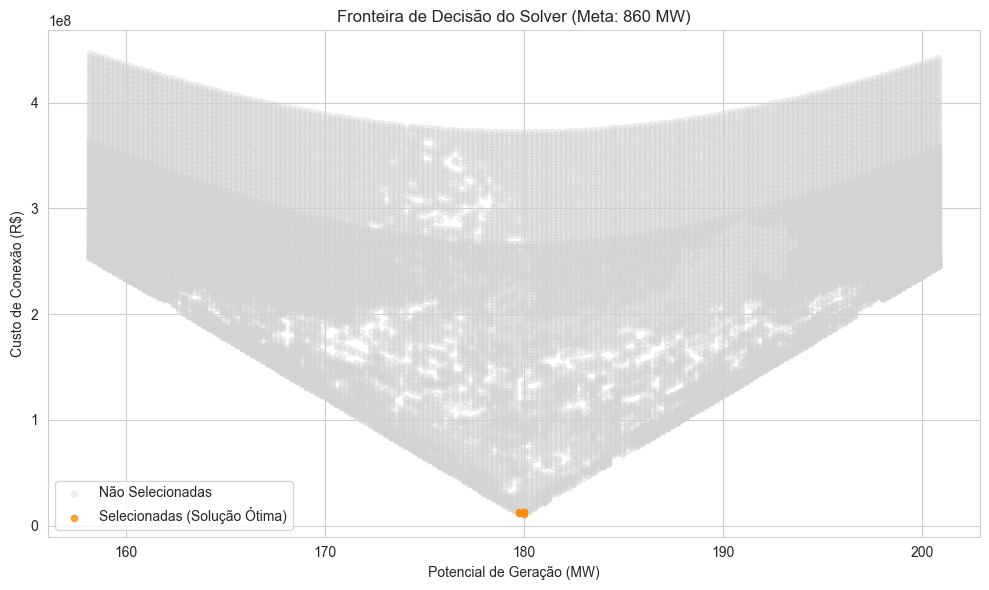

In [13]:
# Configuração estética
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Separar dados para plotagem
selecionadas = df_opt[df_opt["selecionada"] == 1]
nao_selecionadas = df_opt[df_opt["selecionada"] == 0]

# Plotar
plt.scatter(
    nao_selecionadas["potencial_mw"],
    nao_selecionadas["custo_conexao"],
    alpha=0.3,
    label="Não Selecionadas",
    color="lightgrey",
    s=20,
)

plt.scatter(
    selecionadas["potencial_mw"],
    selecionadas["custo_conexao"],
    alpha=0.8,
    label="Selecionadas (Solução Ótima)",
    color="darkorange",
    s=20,
)

# Labels e Títulos
plt.xlabel("Potencial de Geração (MW)")
plt.ylabel("Custo de Conexão (R$)")
plt.title(f"Fronteira de Decisão do Solver (Meta: {META_EXPANSAO_MW} MW)")
plt.legend()
plt.tight_layout()

plt.show()

### 5.2. Mapa de Alocação Ótima

A visualização abaixo espacializa a decisão do algoritmo. Diferente de uma análise puramente estatística, o mapa permite validar a coerência geográfica da solução.

* **Pontos Coloridos:** Representam as usinas selecionadas ($x_i=1$).
* **Escala de Cor:** Indica o custo de conexão. Pontos mais **claros (amarelo)** são mais baratos (próximos à rede). Pontos mais **escuros (vermelho)** indicam onde o modelo foi forçado a gastar mais para atingir a meta.
* **Vazios:** Áreas brancas representam regiões inviáveis (UCs, TIs, relevo acidentado) ou economicamente ineficientes que o modelo descartou.

Gerando mapa de localização...
Diagnóstico: Longitude média dos dados = -44.51
Coordenadas detectadas como Geográficas (Graus).


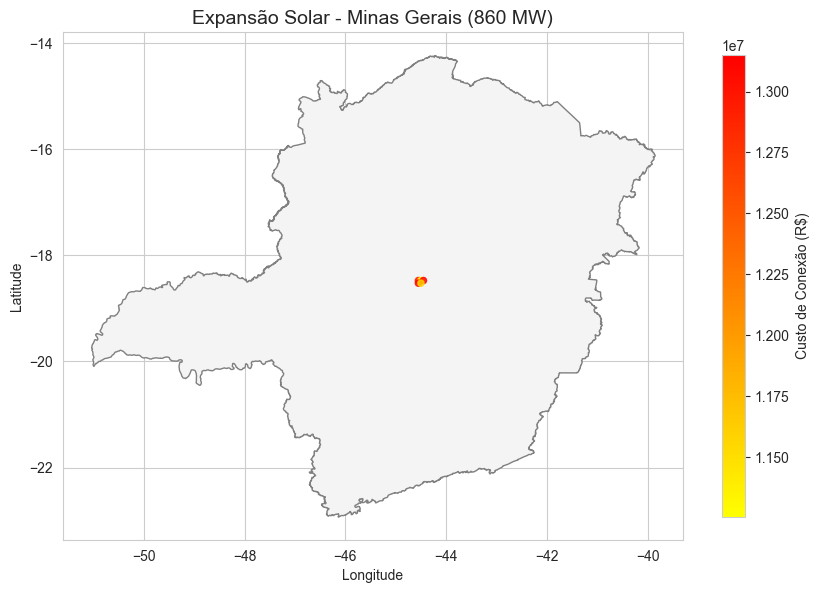

In [14]:
import geopandas as gpd


def plotar_mapa_otimo(dataframe_resultado, meta_mw):
    print("Gerando mapa de localização...")

    # 1. Carregar contorno de MG (Base em Lat/Lon - EPSG:4326)
    url_mg = "https://raw.githubusercontent.com/giuliano-oliveira/geodata-br-states/master/geojson/br_states.json"
    try:
        gdf_br = gpd.read_file(url_mg)
        gdf_mg = gdf_br[gdf_br["SIGLA"] == "MG"]
    except Exception as e:
        print(f"Erro ao baixar mapa base: {e}.")
        return

    # 2. Filtrar usinas selecionadas
    df_selecionadas = dataframe_resultado[
        dataframe_resultado["selecionada"] == 1
    ].copy()

    if len(df_selecionadas) == 0:
        print("Nenhuma área selecionada. Verifique o solver.")
        return

    # 3. Diagnóstico de Coordenadas
    lon_media = df_selecionadas["lon"].mean()
    print(f"Diagnóstico: Longitude média dos dados = {lon_media:.2f}")

    # 4. Criar GeoDataFrame (A Mágica acontece aqui)
    # Se a longitude for um número "normal" (entre -180 e 180), é Geográfico (Graus).
    # Se for gigante (ex: 600000), é Projetado (Metros) e precisamos converter.

    if -180 <= lon_media <= 180:
        # Caso A: Já está em Graus (EPSG:4326 ou 4674)
        print("Coordenadas detectadas como Geográficas (Graus).")
        crs_origem = "EPSG:4326"
    else:
        # Caso B: Está em Metros (Provavelmente SIRGAS 2000 / Polyconic ou UTM)
        # Vamos tentar o padrão do IBGE para mapas nacionais (Polyconic) ou UTM 23S
        print("Coordenadas detectadas como Projetadas (Metros). Convertendo...")
        # Tenta SIRGAS 2000 / Brazil Polyconic (comum em dados oficiais)
        # Se o mapa ficar torto, troque para "EPSG:31983" (UTM 23S)
        crs_origem = "ESRI:102033"

    gdf_usinas = gpd.GeoDataFrame(
        df_selecionadas,
        geometry=gpd.points_from_xy(df_selecionadas.lon, df_selecionadas.lat),
        crs=crs_origem,
    )

    # Converter tudo para o mesmo CRS do mapa de fundo (EPSG:4326)
    if gdf_usinas.crs != gdf_mg.crs:
        gdf_usinas = gdf_usinas.to_crs(gdf_mg.crs)

    # 5. Plotar
    fig, ax = plt.subplots(figsize=(10, 10))

    # Fundo
    gdf_mg.plot(ax=ax, color="#f4f4f4", edgecolor="gray", linewidth=1)

    # Pontos
    gdf_usinas.plot(
        ax=ax,
        column="custo_conexao",
        cmap="autumn_r",
        markersize=20,
        alpha=0.8,
        legend=True,
        legend_kwds={"label": "Custo de Conexão (R$)", "shrink": 0.6},
    )

    plt.title(f"Expansão Solar - Minas Gerais ({meta_mw} MW)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()


# Executar
if "df_opt" in locals():
    plotar_mapa_otimo(df_opt, META_EXPANSAO_MW)

## 6. Conclusão

Este trabalho demonstrou a aplicação de **Programação Inteira Binária (PIB)** para resolver um problema estratégico de infraestrutura nacional: a alocação eficiente de usinas solares para atingir as metas do **PDE 2034**.

### 6.1. Limitações e Trabalhos Futuros
Para fins acadêmicos e de demonstração, este modelo adotou simplificações que podem ser refinadas:

* **Resolução Espacial:** A discretização em células de ~30 km² (grade de 0.05°) foi necessária para a performance do solver em tempo real, mas ignora nuances locais de terreno que seriam capturadas em uma resolução de 1 km².
* **Custo do Terreno:** Assumiu-se custo fundiário zero ou uniforme. Na prática, o preço da terra ($C_{terra}$) deveria ser somado ao custo de conexão.